# Lecture 2 -  NumPy Basics: Arrays and Vectorized Computation

- Numpy is designed for efficiency on large arrays of data
  - NumPy internally stores data in a contiguous block of memory, independent of other built-in Python objects
  - NumPy operations perform complex computations on entire arrays without the need for Python for loops
- NumPy-based algorithms are generally 10 to 100 times faster

In [ ]:
import numpy as np

# numpy operation
my_arr = np.arange(1_000_000) # 백만개 데이터 생성. _ 는 무시됌. comma 대신 표기
%timeit my_arr2 = my_arr * 2

# python list operation
my_list = list(range(1_000_000))
%timeit my_list2 = [x * 2 for x in my_list]

2.79 ms ± 850 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
182 ms ± 61.3 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


- 대용량 데이터를 처리하려 할 때, 그냥 list로 선언하기보다, numpy / pandas를 사용하는 것이 훨씬 빠름.


# 1. The NumPy ndarray: A Multidimensional Array Object

## 1.1 Creating ndarrays

numpy.array
- Use the array function to create an array
- This accepts any sequence-like object (including list, tuple, other arrays, ...)

In [ ]:
data1 = [6, 7.5, 8, 0, 1]

arr1 = np.array(data1)
arr1

array([6. , 7.5, 8. , 0. , 1. ])

- multidimensional array

In [ ]:
data2 = [[1, 2, 3, 4], [5, 6, 7, 8]]

arr2 = np.array(data2)
arr2

array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

In [ ]:
data2 = [[1, 2, 3, 'a'], ['a','b','c','d']]
# data2 = [['a','b','c','d'], ['a','b','c','d']]
arr2 = np.array(data2)
arr2

array([['1', '2', '3', 'a'],
       ['a', 'b', 'c', 'd']], dtype='<U21')

- array자체에 data type이 속성으로 들어감
- 하나의 column마다 다른 데이터 타입을 가질 수 있음 -> 다 달라도 되지 않나?

- inspect the dtype, ndim and shape attributes
  - dtype: type of data in array
  - ndim: number of dimensions
  - shape: size of array

In [ ]:
print(arr2.dtype)
print(arr2.ndim)
print(arr2.shape)

int64
2
(2, 4)


- shape(tuple) : (# of row, # of column)

In [ ]:
print(arr1.dtype)
print(arr1.ndim)
print(arr1.shape)

float64
1
(5,)


- (5) would be ambiguous because Python treats (x) as a simple integer inside parentheses, not a tuple
- so (5,) is used instead of (5) for 1-dimensional array

0-dimansion array
- To represent a scalar value

In [ ]:
data3 = 5
arr3 = np.array(data3)
print(arr3.ndim)
print(arr3.shape)

0
()


- Comparision: 1 dimension array with size 1

In [ ]:
data4 = [5]
arr4 = np.array(data4)
print(arr4.ndim)
print(arr4.shape)

1
(1,)


In [ ]:
data4 = [[5]]
arr4 = np.array(data4)
print(arr4.ndim)
print(arr4.shape)

2
(1, 1)


- broadcasting : 연산을 할 때, shape이 안맞아도 맞춰서 연산을 시켜주는 방식.

numpy.reshape
- change the shape (dimensions) of an array without changing its data
- reshape 결과를 return값에 적용. 기존 input array에는 변형x

In [ ]:
arr5 = np.array([1, 2, 3, 4])
arr6 = arr5.reshape((2, 2)) # (2,2) (x) -> ((2,2)) (o)
print(arr6)
print(arr6.shape)

[[1 2]
 [3 4]]
(2, 2)


In [ ]:
arr5 = np.array([1, 2, 3, 4])
arr6 = arr5.reshape((-1, 2)) # -1 : 컴퓨터 너가 알아서 이 dimension은 맞게 계산해서 넣어라
# but! arr5.reshape((-1,-1,2)) 이런식으로 -1은 여러번 못씀. 최대 1번만 가능.
print(arr6)
print(arr6.shape)

[[1 2]
 [3 4]]
(2, 2)


In [ ]:
arr6 = arr5.reshape((2, 3))

ValueError: cannot reshape array of size 4 into shape (2,3)

numpy.zeros, numpy.ones, numpy.empty
- create array with a given length or shape

In [ ]:
np.zeros(10)    # == np.zeros((10,))

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
np.zeros((3, 6))

array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

In [ ]:
np.empty((2, 3, 4))
# empty는 어떤 상황에 쓰는거지? - zero보다 훨씬 빠름. zero는 array를 메모리 공간에 할당하고 0이라는 데이터를 쓰는것까지 포함하기 때문.

array([[[-0.25, -0.5 ,  0.  , -0.25],
        [ 0.25, -0.5 ,  0.5 , -0.25],
        [ 0.25,  0.  ,  0.5 ,  0.25]],

       [[ 0.25,  0.5 ,  0.  ,  0.25],
        [-0.25,  0.5 , -0.5 ,  0.25],
        [-0.25,  0.  , -0.5 , -0.25]]])

In [ ]:
%timeit np.zeros(1_000_000)
%timeit np.empty(1_000_000)
# us (마이크로 세컨): 백만 분의 1초. ns (나노 세컨): 십억 분의 1초.

378 µs ± 18 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
845 ns ± 335 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


numpy.arange
- array-valued version of the built-in Python range function

In [ ]:
np.arange(15)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

**Exercise #1**
- Create the following arrays using arange(), and reshape()


```
shape: (2, 4)
0 1 2 3
4 5 6 7
```
```
shape: (3, 3)
0 1 2
3 4 5
6 7 8
```

```
shape: (2, 2, 2)
0 1  4 5   
2 3  6 7
```

In [ ]:
arr = np.arange(8).reshape((2, 4))
print(arr)

arr = np.arange(9).reshape((3, 3))
print(arr)

arr = np.arange(8).reshape((2, 2, 2))
print(arr)

[[0 1 2 3]
 [4 5 6 7]]
[[0 1 2]
 [3 4 5]
 [6 7 8]]
[[[0 1]
  [2 3]]

 [[4 5]
  [6 7]]]


## 1.2 Data Types for ndarrays


create array with dtype

In [ ]:
arr1 = np.array([1, 2, 3], dtype=np.float64) # array 생성시 data type 설정 가능. -> data type에 따라 memory size를 다르게 잡게 됌
arr2 = np.array([1, 2, 3], dtype=np.int32)

print(arr1)
print(arr2)


[1. 2. 3.]
[1 2 3]


convert or cast an array from one data type to another

In [ ]:
arr = np.array([1, 2, 3, 4, 5])
float_arr = arr.astype(np.float64) # type을 바꾸고 싶으면 이렇게 새로 만들어야 함
print(float_arr)

arr = np.array([3.7, -1.2, -2.6, 0.5, 12.9, 10.1])
int_arr = arr.astype(np.int32)
print(int_arr)



[1. 2. 3. 4. 5.]
[ 3 -1 -2  0 12 10]


handling array of strings representing numbers

In [ ]:
string_arr = np.array(["1.25", "-9.6", "42"] )
print(string_arr)

arr = string_arr.astype(np.float32)
print(arr)

['1.25' '-9.6' '42']
[ 1.25 -9.6  42.  ]


## 1.3 Creating ndarrays from file

- read a file with Python's built-in open() function


In [ ]:
with open("stock_price.txt", 'r') as file:
  lines = [line.strip() for line in file]

print(lines[:5])

['328.79', '330.92', '331.85', '329.66', '333.75']


- create ndarray with dtype

In [ ]:
prices = np.array(lines, dtype=np.float32)
prices[:5]

array([328.79, 330.92, 331.85, 329.66, 333.75], dtype=float32)

- using np.fromfile()

In [ ]:
# 위처럼 with open으로 하지 말고 아래처럼 하면 간단하게 array 생성 가능

prices = np.fromfile('stock_price.txt', sep='\n', dtype=np.float32)
prices[:5]

array([328.79, 330.92, 331.85, 329.66, 333.75], dtype=float32)

- simple plot with pyplot

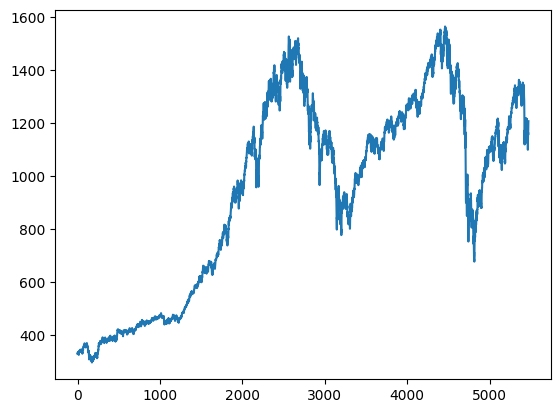

In [ ]:
import matplotlib.pyplot as plt

plt.plot(prices)

## 1.4 Arithmetic with NumPy Arrays
Vectorization
- operations on data without writing any for loops
- any arithmetic operations between equal-size arrays apply the operation element-wise


In [ ]:
arr1 = np.array([[1., 2., 3.], [4., 5., 6.]])
arr2 = np.array([[7., 8., 9.], [10., 11., 12.]])

print(arr1 * arr2)

print(arr2 - arr1)

[[ 7. 16. 27.]
 [40. 55. 72.]]
[[6. 6. 6.]
 [6. 6. 6.]]


Arithmetic operations with scalars
- propagate the scalar argument to each element

In [ ]:
print(arr1 + 1) # scalar 가 피연산자로 들어왔을 때, 내부적으로 array로 변환하여 계산해줌

print(arr1 ** 2)

[[2. 3. 4.]
 [5. 6. 7.]]
[[ 1.  4.  9.]
 [16. 25. 36.]]


## 1.5 Basic Indexing and Slicing

To select a subset of your data or individual elements
- One-dimensional arrays act similarly to Python lists
- array[{start_index}:{end_index}+1]: slice array from start_index to end_index
- Negative indices allow slicing from the end

In [ ]:
arr = np.arange(10)
print(arr)

print(arr[5])

[0 1 2 3 4 5 6 7 8 9]
5


In [ ]:
print(arr[5:8])

[5 6 7]


In [ ]:
print(arr[3:])

[3 4 5 6 7 8 9]


In [ ]:
print(arr[:-2])

[0 1 2 3 4 5 6 7]


In [ ]:
arr[5:8] = 12
print(arr)

[ 0  1  2  3  4 12 12 12  8  9]


Slicing does not copy elements unlike list
- NumPy has been designed to be able to work with very large arrays

In [ ]:
list_a = [1, 2, 3, 4]

list_b = list_a[0:2]
print(list_b)
list_b[0] = 10
print(list_b)

print(list_a)


[1, 2]
[10, 2]
[1, 2, 3, 4]


In [ ]:
arr_a = np.array([1, 2, 3, 4])
arr_b = arr_a[0:2]

print(arr_b)
arr_b[0] = 10
print(arr_b)

print(arr_a)



[1 2]
[10  2]
[10  2  3  4]


- python list에서는 slicing을 하면 객체를 새로 만들어줌 (기존 list를 잘라서 복사)
- numpy array에서는 slicing을 하면 기존의 객체를 참조함. slicing한 값을 담은 array 값을 바꾸면, 기존 array도 바뀐다는 말.
  - 잘라서 복사를 하려면 대용량 데이터가 될수록 시간이 오래 걸려서 복사 기능을 기본으로 제공하지 않음

In [ ]:
# to copy data, use copy()
arr_b = arr_a[0:2].copy()

**Exercise #2-1**
- plot the daily price change (difference from the previous day) from stock price

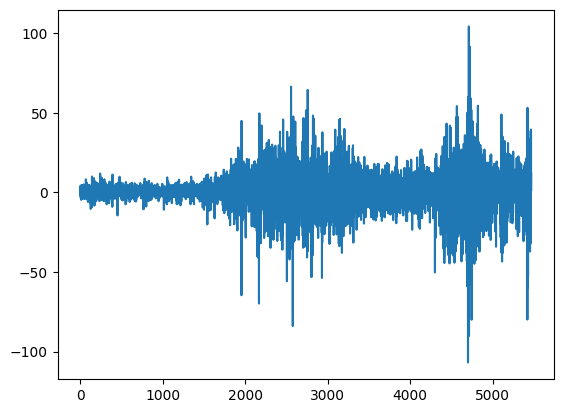

In [ ]:
# plt.plot(prices)

tomorrow_prices = prices[1:]
today_prices = prices[:-1]

daily_price_change = tomorrow_prices - today_prices
plt.plot(daily_price_change)

**Exercise #2-2**
- plot the daily price change percentage

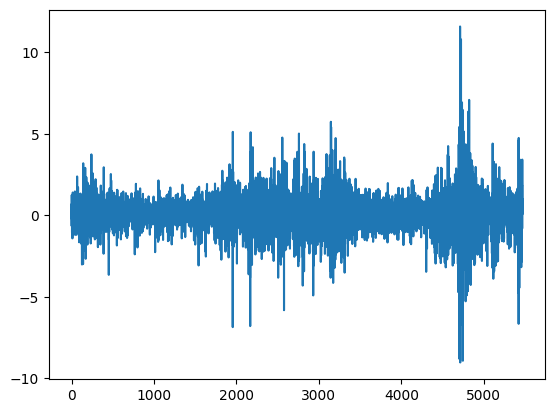

In [ ]:
change_percentage = daily_price_change / today_prices * 100
plt.plot(change_percentage)

two-dimensional array (or multidimensional)

In [ ]:
arr2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
arr2d[2]

array([7, 8, 9])

In [ ]:
print(arr2d[2][2])
print(arr2d[2,2])

9
9


In [ ]:
print(arr2d[1,2])

6


<img src=https://wesmckinney.com/book/images/pda3_0401.png width=40%>

- two-dimensional array slicing
  - slice along axis 0

In [ ]:
arr2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
arr2d[:2]

array([[1, 2, 3],
       [4, 5, 6]])

  - slice along axis 1

In [ ]:
arr2d[:2, 1:]

array([[2, 3],
       [5, 6]])

In [ ]:
arr2d[:,1:]

array([[2, 3],
       [5, 6],
       [8, 9]])

- By mixing integer indexes and slices, you get lower dimensional slices.



In [ ]:
a = arr2d[1, :2]
print(a)

print(a.shape)

[4 5]
(2,)


In [ ]:
a = arr2d[:, 2]
print(a)

print(a.shape)

[3 6 9]
(3,)


<img src=https://wesmckinney.com/book/images/pda3_0402.png width=40%>

## 1.6 Boolean Indexing
- 0인값만 뽑아오기, 1인 값만 뽑아오기

- preperation

In [ ]:
names = np.array(["Bob", "Joe", "Will", "Bob", "Will", "Joe", "Joe"])
data = np.array([[4, 7], [0, 2], [-5, 6], [0, 0], [1, 2], [-12, -4], [3, 4]])
boolean_index = names == "Bob"
boolean_index

array([ True, False, False,  True, False, False, False])

- Like arithmetic operations, comparisons (such as ==) with arrays are also vectorized
- This Boolean array can be passed when indexing the array

In [ ]:
data[boolean_index]

array([[4, 7],
       [0, 0]])

In [ ]:
mask = (names == "Bob") | (names == "Will")
data[mask]

array([[ 4,  7],
       [-5,  6],
       [ 0,  0],
       [ 1,  2]])

In [ ]:
nagative = data < 0
nagative

array([[False, False],
       [False, False],
       [ True, False],
       [False, False],
       [False, False],
       [ True,  True],
       [False, False]])

In [ ]:
data[nagative] = 0
data

array([[4, 7],
       [0, 2],
       [0, 6],
       [0, 0],
       [1, 2],
       [0, 0],
       [3, 4]])

## 1.7 Fancy Indexing
- to describe indexing using integer arrays
- pass a list or ndarray of integers specifying the desired order


- select specific rows


In [ ]:
arr = np.zeros((8, 4))
for i in range(8):
  arr[i] = i   # arr[i,:] = i

arr

array([[0., 0., 0., 0.],
       [1., 1., 1., 1.],
       [2., 2., 2., 2.],
       [3., 3., 3., 3.],
       [4., 4., 4., 4.],
       [5., 5., 5., 5.],
       [6., 6., 6., 6.],
       [7., 7., 7., 7.]])

In [ ]:
arr[[4, 3, 0, 6]]
# = selection & 순서 바꾸기
# 특정 row 가져오는 방법

array([[4., 4., 4., 4.],
       [3., 3., 3., 3.],
       [0., 0., 0., 0.],
       [6., 6., 6., 6.]])

- select specific columns

In [ ]:
arr = np.zeros((8, 4))
for i in range(4):
  arr[:,i] = i

arr

array([[0., 1., 2., 3.],
       [0., 1., 2., 3.],
       [0., 1., 2., 3.],
       [0., 1., 2., 3.],
       [0., 1., 2., 3.],
       [0., 1., 2., 3.],
       [0., 1., 2., 3.],
       [0., 1., 2., 3.]])

In [ ]:
arr[:,[1, 3]]

array([[1., 3.],
       [1., 3.],
       [1., 3.],
       [1., 3.],
       [1., 3.],
       [1., 3.],
       [1., 3.],
       [1., 3.]])

- Passing multiple index arrays

In [ ]:
arr = np.arange(32).reshape((8, 4))
print(arr)

arr[[1, 5, 7, 2], [0, 3, 1, 2]] # [1,0], [5,3] ... 가져오는 것과 결과 동일

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]
 [24 25 26 27]
 [28 29 30 31]]


array([ 4, 23, 29, 10])

## 1.8 Transposing Arrays and Swapping Axes
- Transposing is a special form of reshaping


In [ ]:
arr = np.arange(15).reshape((3, 5))
print(arr)
print(arr.T)

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]
[[ 0  5 10]
 [ 1  6 11]
 [ 2  7 12]
 [ 3  8 13]
 [ 4  9 14]]


In [ ]:
np.dot(arr.T, arr)

array([[125, 140, 155, 170, 185],
       [140, 158, 176, 194, 212],
       [155, 176, 197, 218, 239],
       [170, 194, 218, 242, 266],
       [185, 212, 239, 266, 293]])

In [ ]:
arr.T @ arr   # same as np.dot (matrix multiplication)

array([[125, 140, 155, 170, 185],
       [140, 158, 176, 194, 212],
       [155, 176, 197, 218, 239],
       [170, 194, 218, 242, 266],
       [185, 212, 239, 266, 293]])

- Transposing is a special case of swapping axes

In [ ]:
arr.swapaxes(0, 1) # 특정 축과 특정 축을 swap 하는 함수

array([[ 0,  5, 10],
       [ 1,  6, 11],
       [ 2,  7, 12],
       [ 3,  8, 13],
       [ 4,  9, 14]])

**Exercise #3**
- From a stock price dataset, extract and plot the daily price change percentage for Mondays and Fridays only
- Assumptions
  - the dataset contains only weekdays (Monday to Friday)
  - the data starts from Monday
  - no missing dates in the dataset
- Hint
  - Reshape the data into weeks by reshape(-1, 5)
  - -1 means that NumPy will automatically determine the number of rows based on the array size

In [ ]:
change_percentage.shape # (5469)
week_percentage = change_percentage[:-4].reshape(-1,5)
week_percentage.shape

(1093, 5)

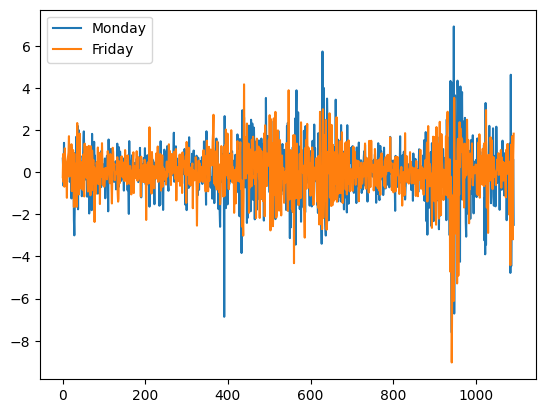

In [ ]:
plt.plot(week_percentage[:,0], label='Monday')
plt.plot(week_percentage[:,-1], label='Friday')
plt.legend()

# 2. Pseudorandom Number Generation
- efficiently generating whole arrays of random values

In [ ]:
samples = np.random.standard_normal(size=(4, 4))
samples

array([[-2.02572976, -0.87954242, -0.76536358,  0.05321488],
       [ 0.07748053,  0.63356068,  0.03476135,  2.46263971],
       [-0.65336366,  1.4684299 , -0.22804165,  0.9793776 ],
       [-0.41194101,  0.24800793, -0.16163392, -0.8197226 ]])

- Python’s built-in random module, by contrast, samples only one value at a time

In [ ]:
from random import normalvariate

N = 1_000_000

%timeit samples = [normalvariate(0, 1) for _ in range(N)]

%timeit np.random.standard_normal(N) # 이게 python library 방식보다 훨씬 빠르다

652 ms ± 4.26 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
32.9 ms ± 5.16 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


- default_rng is recommended instead of np.random
  - "PCG-64" random number generator, based on the Mersenne Twister algorithm, which provides higher-quality random numbers

In [ ]:
rng = np.random.default_rng(seed=12345)
data = rng.standard_normal((2, 3))
data

array([[-1.42382504,  1.26372846, -0.87066174],
       [-0.25917323, -0.07534331, -0.74088465]])

# 3. Universal Functions: Fast Element-Wise Array Functions
- A universal function, or ufunc, is a function that performs element-wise operations on data in ndarrays

- unary universal functions
  - abs, fabs, sqrt, square, exp, round, ...
- binary universal functions
  - add, subtract, multiply, divide, ...


In [ ]:
arr = np.arange(10)
np.sqrt(arr)

array([0.        , 1.        , 1.41421356, 1.73205081, 2.        ,
       2.23606798, 2.44948974, 2.64575131, 2.82842712, 3.        ])

In [ ]:
arr1 = np.arange(10)
arr2 = np.arange(10)

print(np.add(arr1, arr2))
print(np.subtract(arr1, arr2))

%timeit arr3 =np.add(arr1, arr2)
%timeit arr3 = arr1+arr2
# us (마이크로 세컨): 백만 분의 1초. ns (나노 세컨): 십억 분의 1초.

[ 0  2  4  6  8 10 12 14 16 18]
[0 0 0 0 0 0 0 0 0 0]
1.87 µs ± 652 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)
593 ns ± 6.85 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


# 4. Array-Oriented Programming with Arrays


## 4.1 Expressing Conditional Logic as Array Operations
- numpy.where function
  - vectorized version of 'x if condition else y'

In [ ]:
w = -1
a = 10 if w > 0 else 20

a

In [ ]:
xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])
yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])
cond = np.array([True, False, True, True, False])

result = np.where(cond, xarr, yarr) # condition이 True일때는 xarr, False일때는 yarr
result
# 결측치 처리할때 where 유용하게 사용할 수 있음.

array([1.1, 2.2, 1.3, 1.4, 2.5])

- The second and third arguments can be scalars.
- A typical use of where in data analysis is to produce a new array of values based on another array

In [ ]:
rng = np.random.default_rng(seed=12345)
arr = rng.standard_normal((4, 4))
print(arr)

new_arr1 = np.where(arr > 0, 2, -2)
print(new_arr1)

new_arr2 = np.where(arr > 0, arr, 0)
print(new_arr2)


[[-1.42382504  1.26372846 -0.87066174 -0.25917323]
 [-0.07534331 -0.74088465 -1.3677927   0.6488928 ]
 [ 0.36105811 -1.95286306  2.34740965  0.96849691]
 [-0.75938718  0.90219827 -0.46695317 -0.06068952]]
[[-2  2 -2 -2]
 [-2 -2 -2  2]
 [ 2 -2  2  2]
 [-2  2 -2 -2]]
[[0.         1.26372846 0.         0.        ]
 [0.         0.         0.         0.6488928 ]
 [0.36105811 0.         2.34740965 0.96849691]
 [0.         0.90219827 0.         0.        ]]


## 4.2 Mathematical and Statistical Methods
- aggregations
  - sum, mean, std, var, min, max, argmin, argmax
    - argmax :함수 f(x)를 최대로 하는 x 값을 구한다
  - an optional axis argument that computes the statistic over the given axis


In [ ]:
arr = rng.standard_normal((5, 4))
print(arr)

print(arr.mean())
print(arr.mean(axis=0))
print(arr.mean(axis=1))

[[ 0.78884434 -1.25666813  0.57585751  1.39897899]
 [ 1.32229806 -0.29969852  0.90291934 -1.62158273]
 [-0.15818926  0.44948393 -1.34360107 -0.08168759]
 [ 1.72473993  2.61815943  0.77736134  0.8286332 ]
 [-0.95898831 -1.20938829 -1.41229201  0.54154683]]
0.17933634979615845
[ 0.54374095  0.06037768 -0.09995098  0.21317774]
[ 0.37675318  0.07598404 -0.2834985   1.48722347 -0.75978045]


In [ ]:
print(arr.argmax())
print(arr.argmax(axis=0))
print(arr.argmax(axis=1))


13
[3 3 1 0]
[3 0 1 1 3]


- difference between consecutive elements
  - numpy.diff(array, axis=-1)
  - By default, axis=-1 means last one (columns for 2d arrays)

In [ ]:
arr = np.arange(10).reshape(5,2)
print(arr)

print(np.diff(arr)) # np.diff(arr, axis=1)
print(np.diff(arr, axis=0))


[[0 1]
 [2 3]
 [4 5]
 [6 7]
 [8 9]]
[[1]
 [1]
 [1]
 [1]
 [1]]
[[2 2]
 [2 2]
 [2 2]
 [2 2]]


- accumulation functions
  - cumsun, cumprod

In [ ]:
arr = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])
arr.cumsum()

In [ ]:
arr = np.array([[0, 1, 2], [3, 4, 5], [6, 7, 8]])
print(arr)

print(arr.cumsum(axis=0))
print(arr.cumsum(axis=1))

## 4.3 Methods for Boolean Arrays

- Boolean values are coerced to 1 (True) and 0 (False)
- sum is often used as a means of counting True values
- any(): check if any is True
- all(): check if all are True

In [ ]:
arr = rng.standard_normal(5)
print(arr)
print((arr > 0).sum())
print((arr > 0).any())
print((arr > 0).all())

[ 0.78884434 -1.25666813  0.57585751  1.39897899  1.32229806]
4
True
False


## 4.4 Sorting
- sorted in place

In [ ]:
arr = rng.standard_normal((5, 3))
print(arr)

arr.sort(axis=1)
print(arr)

## 4.5 Unique and Other Set Logic
- unique, intersect1d, union1d, in1d, setdiff1d, setxor1d


In [ ]:
names = np.array(["Bob", "Will", "Joe", "Bob", "Will", "Joe", "Joe"])
np.unique(names)

array(['Bob', 'Joe', 'Will'], dtype='<U4')

**Exercise #4**
- we want to analyze the trend of stock prices based on weekdays
- count the number of days the stock price increased for each weekday

# 5. File Input and Output with Arrays
- numpy.save
- numpy.load


In [ ]:
arr = np.arange(10)

np.save("test.npy", arr)

arr_load = np.load("test.npy")
arr_load


# 6. Linear Algebra
- numpy.linalg has standard set of matrix decompositions
  - diag, dot, lstsq, trace, det, eig, inv, svd, ...

# 7. Example: Random Walks


- Puer Python

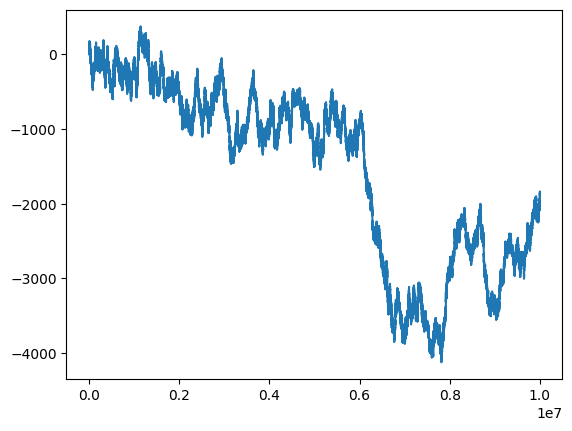

In [ ]:
import random
import matplotlib.pyplot as plt

position = 0
walk = [position]
nsteps = 10000000
for _ in range(nsteps):
    step = 1 if random.randint(0, 1) else -1
    position += step
    walk.append(position)

plt.plot(walk)

- Numpy

4998240


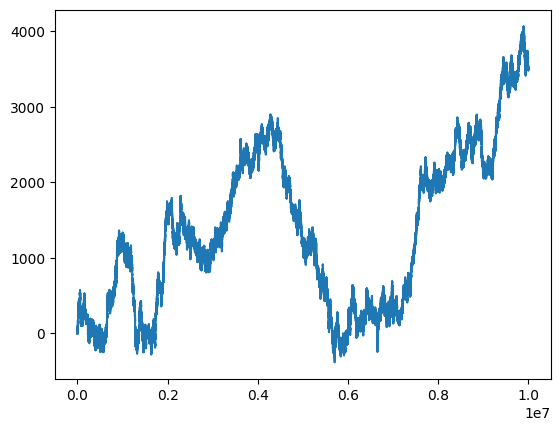

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

nsteps = 10000000
rng = np.random.default_rng(seed=12345)
draws = rng.integers(0, 2, size=nsteps)
steps = np.where(draws == 0, 1, -1)
walk = steps.cumsum()

# counting
count = (draws==1).sum()
print(count)

# plot walk
plt.plot(walk)
